In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pathlib

#Loading Data and Splitting into Training and Testing Datasets

data_path = pathlib.Path("../data/trait_counts_cleaned.csv")   
df = pd.read_csv(data_path)

X = df.drop(columns=["top_four"])
y = df["top_four"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          
)
feature_columns = df.drop(columns = ['top_four']).columns.tolist()

In [4]:
#Standardizing Features 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm_scaled_training_data = pd.DataFrame(X_train_scaled, columns = feature_columns)
svm_scaled_training_data.to_csv("../data/svm_scaled_training_data.csv", index=False)

svm_scaled_testing_data = pd.DataFrame(X_test_scaled, columns = feature_columns)
svm_scaled_testing_data.to_csv("../data/svm_scaled_testing_data.csv", index=False)

Accuracy: 0.7228

              precision    recall  f1-score   support

           0       0.71      0.76      0.73      1077
           1       0.74      0.69      0.71      1077

    accuracy                           0.72      2154
   macro avg       0.72      0.72      0.72      2154
weighted avg       0.72      0.72      0.72      2154



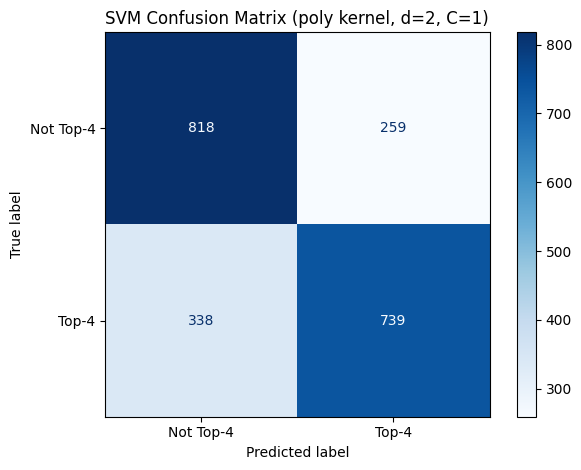

In [ ]:
# Model 1

svc = SVC(
    kernel="poly",      
    degree=2,           
    coef0=1,            
    C=1,                
    probability=False,  
    random_state=42
)
svc.fit(X_train_scaled, y_train)

y_pred = svc.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Top-4", "Top-4"],
    cmap="Blues",
    values_format="d"
)
plt.title("SVM Confusion Matrix (poly kernel, d=2, C=1)")
plt.tight_layout()
plt.show()


===== poly_d2_C0.1 =====
Accuracy: 0.7071
              precision    recall  f1-score   support

           0       0.68      0.77      0.72      1077
           1       0.74      0.65      0.69      1077

    accuracy                           0.71      2154
   macro avg       0.71      0.71      0.71      2154
weighted avg       0.71      0.71      0.71      2154



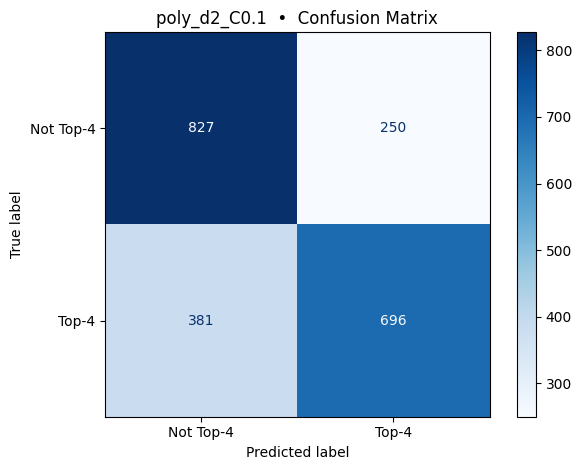


===== poly_d2_C10 =====
Accuracy: 0.7219
              precision    recall  f1-score   support

           0       0.70      0.77      0.73      1077
           1       0.74      0.68      0.71      1077

    accuracy                           0.72      2154
   macro avg       0.72      0.72      0.72      2154
weighted avg       0.72      0.72      0.72      2154



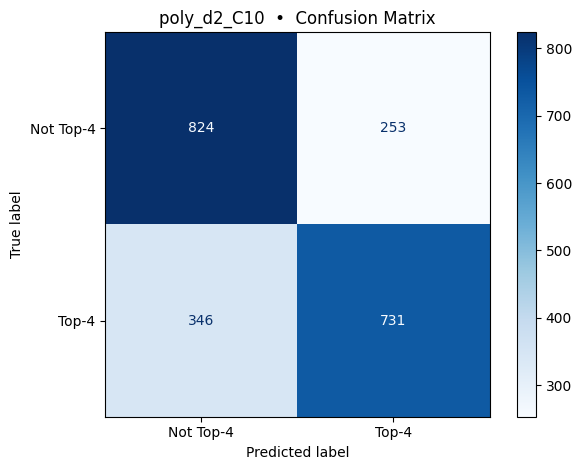


===== rbf_C0.1 =====
Accuracy: 0.6880
              precision    recall  f1-score   support

           0       0.68      0.72      0.70      1077
           1       0.70      0.65      0.68      1077

    accuracy                           0.69      2154
   macro avg       0.69      0.69      0.69      2154
weighted avg       0.69      0.69      0.69      2154



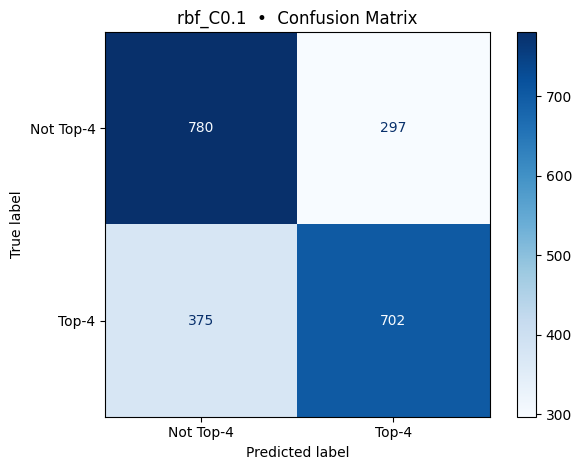


===== rbf_C1 =====
Accuracy: 0.7154
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      1077
           1       0.72      0.70      0.71      1077

    accuracy                           0.72      2154
   macro avg       0.72      0.72      0.72      2154
weighted avg       0.72      0.72      0.72      2154



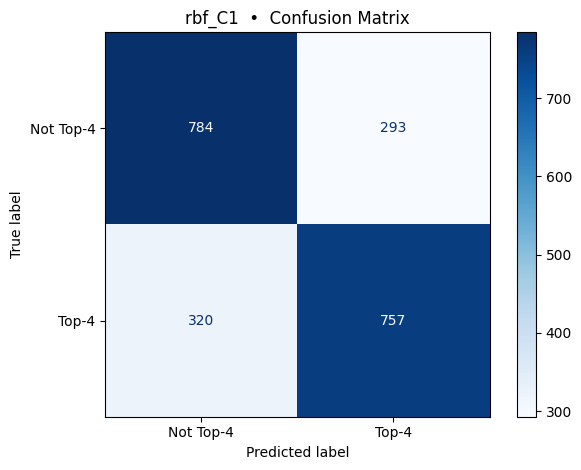


===== rbf_C10 =====
Accuracy: 0.7117
              precision    recall  f1-score   support

           0       0.71      0.72      0.72      1077
           1       0.72      0.70      0.71      1077

    accuracy                           0.71      2154
   macro avg       0.71      0.71      0.71      2154
weighted avg       0.71      0.71      0.71      2154



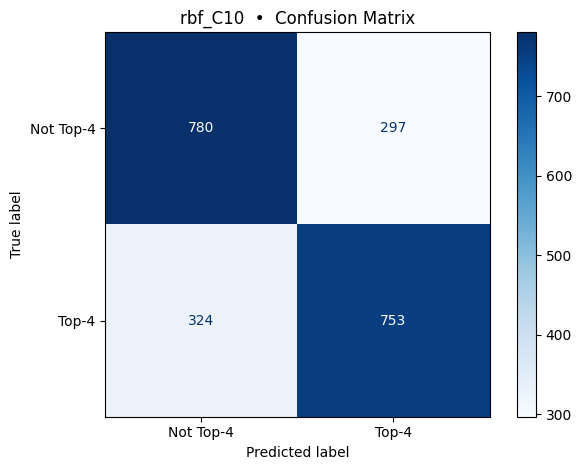


===== linear_C0.1 =====
Accuracy: 0.6964
              precision    recall  f1-score   support

           0       0.68      0.74      0.71      1077
           1       0.71      0.65      0.68      1077

    accuracy                           0.70      2154
   macro avg       0.70      0.70      0.70      2154
weighted avg       0.70      0.70      0.70      2154



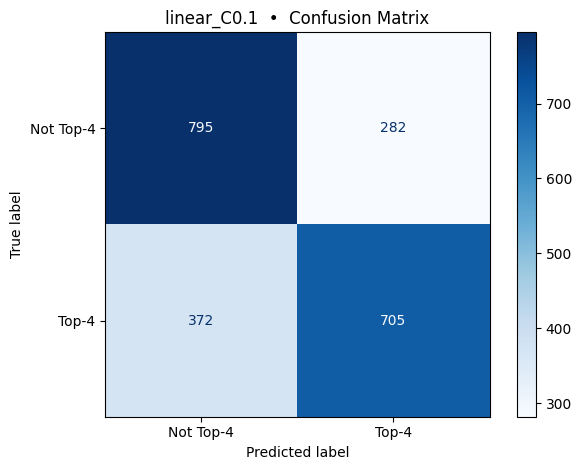


===== linear_C1 =====
Accuracy: 0.6950
              precision    recall  f1-score   support

           0       0.68      0.74      0.71      1077
           1       0.71      0.65      0.68      1077

    accuracy                           0.69      2154
   macro avg       0.70      0.69      0.69      2154
weighted avg       0.70      0.69      0.69      2154



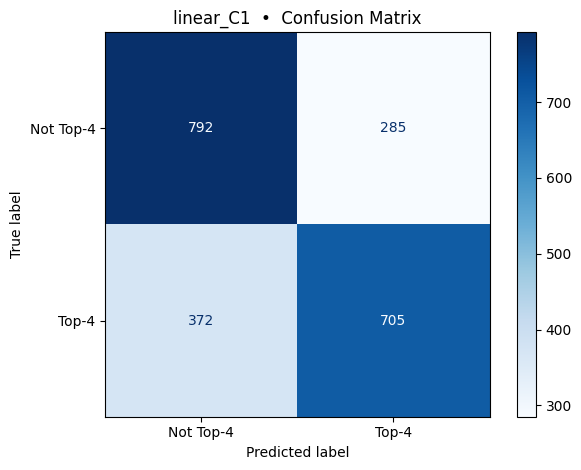


===== linear_C10 =====
Accuracy: 0.6955
              precision    recall  f1-score   support

           0       0.68      0.73      0.71      1077
           1       0.71      0.66      0.68      1077

    accuracy                           0.70      2154
   macro avg       0.70      0.70      0.69      2154
weighted avg       0.70      0.70      0.69      2154



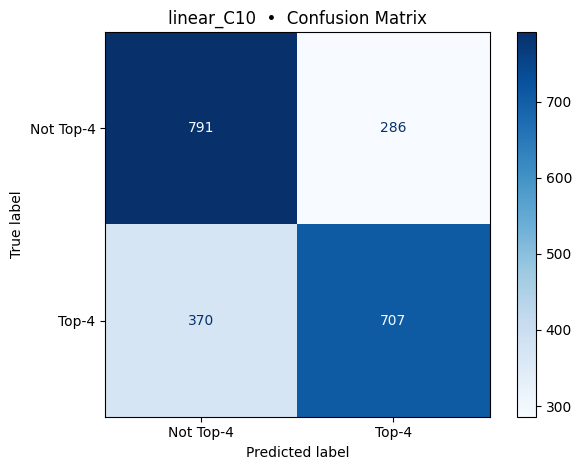

In [ ]:
#Models 2-9

model_specs = [
    # --- Polynomial kernel (degree = 2) --------------------------------------
    ("poly_d2_C0.1", dict(kernel="poly", degree=2, coef0=1, C=0.1, random_state=42)),
    ("poly_d2_C10",  dict(kernel="poly", degree=2, coef0=1, C=10,  random_state=42)),
    # --- RBF kernel ----------------------------------------------------------
    ("rbf_C0.1", dict(kernel="rbf", C=0.1, gamma="scale", random_state=42)),
    ("rbf_C1",   dict(kernel="rbf", C=1,   gamma="scale", random_state=42)),
    ("rbf_C10",  dict(kernel="rbf", C=10,  gamma="scale", random_state=42)),
    # --- Linear kernel -------------------------------------------------------
    ("linear_C0.1", dict(kernel="linear", C=0.1, random_state=42)),
    ("linear_C1",   dict(kernel="linear", C=1,   random_state=42)),
    ("linear_C10",  dict(kernel="linear", C=10,  random_state=42)),
]

for name, svc_kwargs in model_specs:
    print(f"\n===== {name} =====")
    clf = SVC(**svc_kwargs)
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)

    # Accuracy & report for each model
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion-matrix plot for each model
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Not Top-4", "Top-4"],
        cmap="Blues",
        values_format="d"
    )
    disp.ax_.set_title(f"{name}  •  Confusion Matrix")
    plt.tight_layout()
    plt.show()

poly d=2 C=1 (visualised with linear SVM)  –  PCA-space accuracy: 0.492


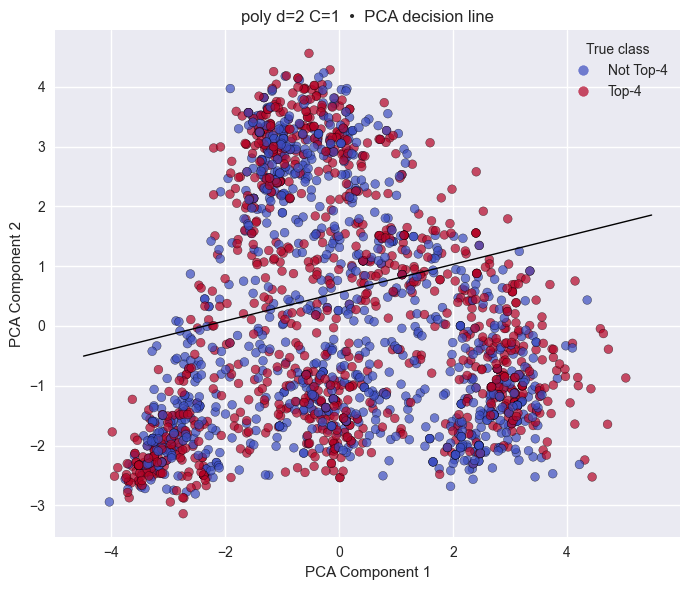

poly d=2 C=10 (visualised with linear SVM)  –  PCA-space accuracy: 0.492


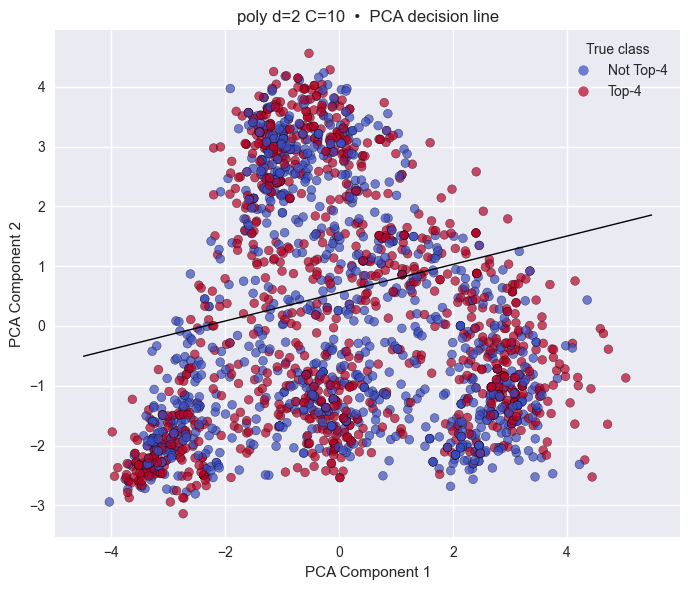

rbf C=1 (visualised with linear SVM)  –  PCA-space accuracy: 0.492


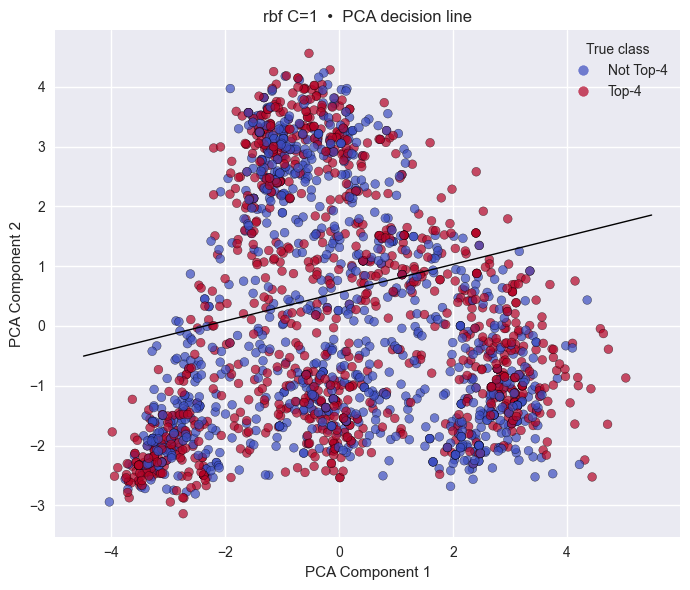

In [7]:
from sklearn.decomposition import PCA
import numpy as np
import itertools

pca = PCA(n_components=2, random_state=42)
X_tr_pca = pca.fit_transform(X_train_scaled)
X_te_pca = pca.transform(X_test_scaled)

BEST_MODELS = [
    ("poly d=2 C=1",  dict(kernel="poly", degree=2, coef0=1, C=1,  random_state=42)),
    ("poly d=2 C=10", dict(kernel="poly", degree=2, coef0=1, C=10, random_state=42)),
    ("rbf C=1",       dict(kernel="rbf", gamma="scale",       C=1,  random_state=42)),
]

def plot_pca_separator(ax, clf, title):
    w = clf.coef_[0] if hasattr(clf, "kernel") and clf.kernel == "linear" else None
    if w is None:
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                             np.linspace(y_min, y_max, 400))
        Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
        ax.contour(xx, yy, Z.reshape(xx.shape), levels=[0], colors="k", linewidths=1)
    else:
        x_vals = np.linspace(*ax.get_xlim(), 200)
        y_vals = -(w[0] * x_vals + clf.intercept_[0]) / w[1]
        ax.plot(x_vals, y_vals, "k-", linewidth=1)

    ax.set_title(title)

plt.style.use("seaborn-v0_8")  

for name, params in BEST_MODELS:
    linear_params = dict(kernel="linear", C=params["C"], random_state=42)
    clf = SVC(**linear_params).fit(X_tr_pca, y_train)

    # Accuracy on held-out test data (still PCA-reduced)
    acc = accuracy_score(y_test, clf.predict(X_te_pca))
    print(f"{name} (visualised with linear SVM)  –  PCA-space accuracy: {acc:.3f}")

    fig, ax = plt.subplots(figsize=(7, 6))
    # scatter test points
    scatter = ax.scatter(
        X_te_pca[:, 0], X_te_pca[:, 1],
        c=y_test, cmap="coolwarm", edgecolor="k", alpha=0.7, s=40
    )
    plot_pca_separator(ax, clf, f"{name}  •  PCA decision line")

    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    handles, _ = scatter.legend_elements()
    ax.legend(handles, ["Not Top-4", "Top-4"], title="True class")
    plt.tight_layout()
    plt.show()